In [10]:
import math
from collections import Counter

In [11]:
def extended_gcd(a, b):
    if a == 0:
        return b, 0, 1
    
    g, x1, y1 = extended_gcd(b % a, a)
    x = y1 - (b // a) * x1
    y = x1
    
    return g, x, y

def mod_inverse(a, m):
    a %= m 
    g, x, _ = extended_gcd(a, m)
    
    return x % m if g==1 else None


In [12]:
def solve_congruence(a, b, m):
    a_mod = a % m
    b_mod = b % m
    
    g, _, _ = extended_gcd(a_mod, m)
    
    if b_mod % g != 0:
        return []
        
    a_prime = a_mod // g
    b_prime = b_mod // g
    m_prime = m // g
    
    inv_a = mod_inverse(a_prime, m_prime)

    x0 = (inv_a * b_prime) % m_prime
    
    solutions = []
    for k in range(g):
        sol = (x0 + k * m_prime) % m
        solutions.append(sol)
        
    return sorted(solutions)

In [13]:
def solve_system(a, b, c, d, m):
    A = (a - c) % m
    B = (b - d) % m
    
    x_solutions = solve_congruence(A, B, m)
    
    if not x_solutions:
        return []
        
    results = []
    for x in x_solutions:
        y = (b - a * x) % m
        results.append((x, y))
        
    return results

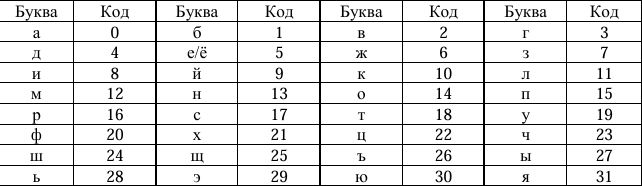
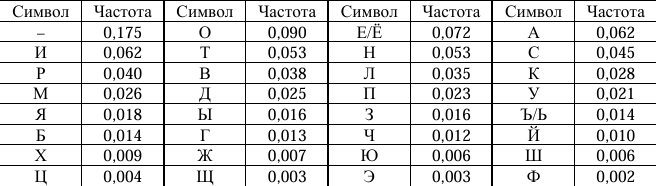

In [14]:
ALPHABET = "абвгдежзийклмнопрстуфхцчшщъыьэюя"
RAW_FREQ_DATA = {
    '-': 0.175,
    'о': 0.090,
    'е': 0.072,
    'ё': 0.072,
    'а': 0.062,
    'и': 0.062,
    'т': 0.053,
    'н': 0.053,
    'с': 0.045,
    'р': 0.040,
    'в': 0.038,
    'л': 0.035,
    'к': 0.028,
    'м': 0.026,
    'д': 0.025,
    'п': 0.023,
    'у': 0.021,
    'я': 0.018,
    'ы': 0.016,
    'з': 0.016,
    'ъ': 0.014,
    'ь': 0.014,
    'б': 0.014,
    'г': 0.013,
    'ч': 0.012,
    'й': 0.010,
    'х': 0.009,
    'ж': 0.007,
    'ю': 0.006,
    'ш': 0.006,
    'ц': 0.004,
    'щ': 0.003,
    'э': 0.003,
    'ф': 0.002
}

M = len(ALPHABET)

In [15]:
def text_to_codes(text):
    """Конвертирует строку в список кодов (индексов в ALPHABET)."""
    codes = []
    for char in text.lower():
        if char == 'ё':
            char = 'е'
        if char in ALPHABET:
            codes.append(ALPHABET.index(char))
    return codes

def codes_to_text(codes):
    """Конвертирует список кодов обратно в строку."""
    return "".join(ALPHABET[c] for c in codes)

def calculate_score(plain_text):
    """Оценивает близость частотного профиля текста к эталону RAW_FREQ_DATA."""
    counts = Counter(plain_text.lower())
    total_len = sum(counts.values())
    
    if total_len == 0:
        return 0.0
        
    vec_actual = []
    vec_target = []
    
    for char in ALPHABET:
        actual_freq = counts.get(char, 0) / total_len
        vec_actual.append(actual_freq)
        
        target_freq = RAW_FREQ_DATA.get(char, 0.0)
        vec_target.append(target_freq)
        
    dot_product = sum(a * b for a, b in zip(vec_actual, vec_target))
    norm_a = math.sqrt(sum(a * a for a in vec_actual))
    norm_b = math.sqrt(sum(b * b for b in vec_target))
    
    if norm_a == 0 or norm_b == 0:
        return 0.0
        
    return dot_product / (norm_a * norm_b)

In [16]:
def get_top_letters(ciphertext):
    clean_text = ""
    for char in ciphertext.lower():
        if char == 'ё': char = 'е'
        if char in ALPHABET:
            clean_text += char
            
    counts = Counter(clean_text)
    total = sum(counts.values())
    
    sorted_chars = []
    for char, count in counts.most_common():
        freq = count / total
        sorted_chars.append((char, freq))
        
    return sorted_chars

ciph_var1 = "щковмтчгфюсякяфртичгфдесявжтрдясзруярдэсчфбефючхрэръвжмвгячхбрйебэчфчфгстнгюамвмякуежюутвщжнбеъкгфнчдщтндвсэчфкфмкукфмвежвэвссолкмгкжкфявруэеймчдфеэебчдмтвгяромеъвмч"
analysis = get_top_letters(ciph_var1)

In [17]:
import math

LOG_FILE = "analysis_log.txt"

def write_log(message):
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(message + "\n")
        print(message)

def decrypt_affine(ciphertext, a, b):
    inv_a = mod_inverse(a, M)
    if inv_a is None: 
        return ""
    
    plain_codes = []
    for char in ciphertext.lower():
        if char == 'ё': 
            char = 'е'
        
        if char in ALPHABET:
            y_code = ALPHABET.index(char)
            x_code = (inv_a * (y_code - b)) % M
            plain_codes.append(x_code)
            
    return codes_to_text(plain_codes)

def find_key_and_decrypt(ciphertext):
    write_log(f"\n--- НАЧАЛО АНАЛИЗА ВАРИАНТА ---")
    write_log(f"Шифр-текст: {ciphertext}")
    
    cipher_stats = get_top_letters(ciphertext)
    if len(cipher_stats) < 2:
        write_log("Ошибка: недостаточно данных для анализа.")
        return None
        
    c_char1, _ = cipher_stats[0]
    c_char2, _ = cipher_stats[1]
    
    code_c1 = ALPHABET.index(c_char1)
    code_c2 = ALPHABET.index(c_char2)
    
    write_log(f"Топ-2 буквы ШТ: '{c_char1}'({code_c1}), '{c_char2}'({code_c2})")
    
    candidates = [k for k in RAW_FREQ_DATA.keys() if k != '-']
    candidates.sort(key=lambda x: -RAW_FREQ_DATA[x])
    top_plain = candidates[:8]
    
    best_score = -1
    best_result = None
    
    attempts = 0
    
    for i, p_char1 in enumerate(top_plain):
        for j, p_char2 in enumerate(top_plain):
            if i == j: continue
            
            temp_p1 = 'е' if p_char1 == 'ё' else p_char1
            temp_p2 = 'е' if p_char2 == 'ё' else p_char2
            
            if temp_p1 not in ALPHABET or temp_p2 not in ALPHABET:
                continue
                
            code_x1 = ALPHABET.index(temp_p1)
            code_x2 = ALPHABET.index(temp_p2)
            
            solutions = solve_system(code_x1, code_c1, code_x2, code_c2, M)
            
            if not solutions:
                continue
                
            for sol_a, sol_b in solutions:
                if math.gcd(sol_a, M) != 1:
                    continue
                    
                attempts += 1
                
                plaintext = decrypt_affine(ciphertext, sol_a, sol_b)
                score = calculate_score(plaintext)
                
                log_line = f"({p_char1},{p_char2}) -> Key:({sol_a},{sol_b}) | Score:{score:.4f} | Text:{plaintext[:50]}..."
                write_log(log_line)
                
                if score > best_score:
                    best_score = score
                    best_result = (sol_a, sol_b, plaintext)
                    
                if score >= 0.80:
                    write_log(f"*** КЛЮЧ НАЙДЕН (Score={score:.4f}) ***")
                    return (sol_a, sol_b, plaintext)
                    
    write_log(f"Перебор завершен. Проверено: {attempts}. Лучший Score: {best_score:.4f}")
    if best_result:
        a, b, text = best_result
        write_log(f"ЛУЧШИЙ РЕЗУЛЬТАТ: Key=({a}, {b})\nText: {text}")
        return (a, b, text)
    return None

In [ ]:
def run_menu():    
    while True:
        choice = input("Выберите пункт меню:\n 1. Проверка математики\n 2. Выполнение варианта\n 3. Выход").strip()
        
        if choice == '1':
            sub_choice = input("\nПодпункт: \n1. Обратный элемент\n 2. Сравнение ax=b\n 3. Система уравнений\n-> ")
            
            if sub_choice == '1':
                try:
                    a = int(input("a = "))
                    m = int(input("m = "))
                    res = mod_inverse(a, m)
                    
                    msg = f"[TEST 2.1] Input: a={a}, m={m} -> Result: {res}"
                    write_log(msg)
                    
                    if res is not None:
                        check = (a * res) % m
                        write_log(f"[CHECK] ({a}*{res})%{m} = {check}")
                        
                except ValueError:
                    write_log("[ERROR] Invalid input for 2.1")
                    
            elif sub_choice == '2':
                try:
                    a = int(input("a = "))
                    b = int(input("b = "))
                    m = int(input("m = "))
                    sols = solve_congruence(a, b, m)
                    
                    msg = f"[TEST 2.2] Input: a={a}, b={b}, m={m} -> Solutions: {sols}"
                    write_log(msg)
                    
                except ValueError:
                    write_log("[ERROR] Invalid input for 2.2")
                    
            elif sub_choice == '3':
                try:
                    a = int(input("a = "))
                    b = int(input("b = "))
                    c = int(input("c = "))
                    d = int(input("d = "))
                    m = int(input("m = "))
                    sols = solve_system(a, b, c, d, m)
                    
                    msg = f"[TEST 2.3] Input: sys({a},{b};{c},{d}) mod {m} -> Solutions: {sols}"
                    write_log(msg)
                    
                except ValueError:
                    write_log("[ERROR] Invalid input for 2.3")
            else:
                print("Неверный выбор подпункта.")

        elif choice == '2':
            find_key_and_decrypt(ciph_var1)

        elif choice == '3':
            write_log("--- ВЫХОД ИЗ ПРОГРАММЫ ---")
            print("Выход. Все результаты сохранены в", LOG_FILE)
            break
        
        else:
            print("Пожалуйста, выберите 1, 2 или 3.")

run_menu()


--- НАЧАЛО АНАЛИЗА ВАРИАНТА ---
Шифр-текст: щковмтчгфюсякяфртичгфдесявжтрдясзруярдэсчфбефючхрэръвжмвгячхбрйебэчфчфгстнгюамвмякуежюутвщжнбеъкгфнчдщтндвсэчфкфмкукфмвежвэвссолкмгкжкфявруэеймчдфеэебчдмтвгяромеъвмч
Топ-2 буквы ШТ: 'в'(2), 'ф'(20)
(о,а) -> Key:(1,20) | Score:0.6740 | Text:ецъошюгпакэлцлаьюфгпарсэлотюьрлэуьяльрйэгансакгбьй...
(о,а) -> Key:(17,20) | Score:0.6362 | Text:хцъошюуяакныцыаьюфуяарбныотюьрынгьпыьрщнуаэбакусьщ...
(о,и) -> Key:(13,12) | Score:0.6180 | Text:бцкоаючуиъщяцяифюмчуишэщяовюфшящзфгяфшхщчийэиъчнфх...
(о,и) -> Key:(29,12) | Score:0.7175 | Text:сцкоаюзгиъйпцпифюмзгишнйповюфшпйчфупфшейзищниъзэфе...
(а,о) -> Key:(15,2) | Score:0.7226 | Text:щшфацрыподбушуотръыпоюнбуаьртюублтяутюхбыоснодыэтх...
(а,о) -> Key:(31,2) | Score:0.7236 | Text:йшфацрляодсгшготръляоюэсгаьртюгсытпгтюеслобэодлнте...
(а,т) -> Key:(1,2) | Score:0.7429 | Text:чимакрхбтьпэиэторжхбтвгпэадровэпеосэовыпхтягтьхуоы...
(а,т) -> Key:(17,2) | Score:0.9266 | Text:зимакрестьянинторжествуянадровняхобновляе